<a href="https://colab.research.google.com/github/Tehila-BD/cloud-computing/blob/main/Tutorial6_mqtt_exampleCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **שימו לב - ברגע שאתם מעלים את המחברת לגיטהאב שלכם תמחקו את ה key!**



In [24]:
pip install paho-mqtt

In [25]:
import paho.mqtt.client as mqtt
import json

# Callback function for when a message is received
def on_message(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())

        # Extract values with lowercase field names
        temperature = data.get("temperature", "N/A")
        humidity = data.get("humidity", "N/A")
        soil= data.get("soil", "N/A")
        print(f"Temperature: {temperature}°C, Humidity: {humidity}%")

    except json.JSONDecodeError:
        print("Received invalid JSON data")
# MQTT setup
broker = "io.adafruit.com"
username = "braude4"   #insert Adafruit user name

topic = f"{username}/feeds/json"
client = mqtt.Client()
client.username_pw_set(username,aio_key)
client.on_message = on_message

client.connect(broker, 1883, 60)
client.subscribe(topic)

print(f"Subscribed to MQTT topic: {topic}")
client.loop_forever()



/tmp/ipykernel_2638/238376799.py:22: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Subscribed to MQTT topic: braude4/feeds/json
Temperature: 25.6°C, Humidity: 48.0%
Temperature: 25.6°C, Humidity: 48.0%


KeyboardInterrupt: 

In [26]:
import requests

USERNAME = "braude4"   #insert Adafruit user name

FEED = "json"

url = f"https://io.adafruit.com/api/v2/{USERNAME}/feeds/{FEED}/data"
headers = {"X-AIO-Key": AIO_KEY}

response = requests.get(url, headers=headers)
data = response.json()

for item in data[:100]:
    print(f"Value: {item['value']}, Time: {item['created_at']}")


Value: {"temperature": 25.60, "humidity": 48.00, "tempThreshold": 28.00, "humThreshold": 40.00}, Time: 2026-05-13T09:00:50Z
Value: {"temperature": 25.60, "humidity": 48.00, "tempThreshold": 28.00, "humThreshold": 40.00}, Time: 2026-05-13T09:00:40Z
Value: {"temperature": 25.60, "humidity": 48.00, "tempThreshold": 28.00, "humThreshold": 40.00}, Time: 2026-05-13T09:00:29Z
Value: {"temperature": 25.60, "humidity": 48.00, "tempThreshold": 28.00, "humThreshold": 40.00}, Time: 2026-05-13T09:00:19Z
Value: {"temperature": 25.60, "humidity": 49.00, "tempThreshold": 28.00, "humThreshold": 40.00}, Time: 2026-05-13T09:00:09Z
Value: {"temperature": 25.60, "humidity": 49.00, "tempThreshold": 28.00, "humThreshold": 40.00}, Time: 2026-05-13T08:59:59Z
Value: {"temperature": 25.60, "humidity": 49.00, "tempThreshold": 28.00, "humThreshold": 40.00}, Time: 2026-05-13T08:59:50Z
Value: {"temperature": 25.60, "humidity": 49.00, "tempThreshold": 28.00, "humThreshold": 40.00}, Time: 2026-05-13T08:59:40Z
Value: {

In [27]:
# Feeds
aio_username = "braude4"

envFeed = f"{aio_username}/feeds/json"
tempFeed = f"{aio_username}/feeds/temperature"
humFeed = f"{aio_username}/feeds/humidity"
tempThreshFeed = f"{aio_username}/feeds/t_threshold"
humThreshFeed = f"{aio_username}/feeds/h_threshold"

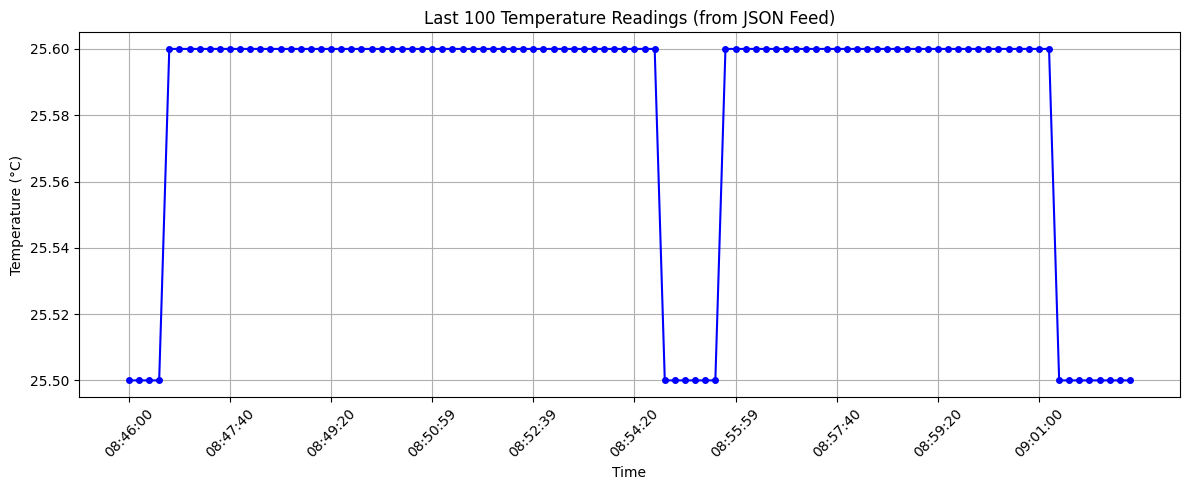

In [36]:
import requests
import json
import matplotlib.pyplot as plt
from datetime import datetime

USERNAME = "braude4"

FEED = "json"

url = f"https://io.adafruit.com/api/v2/{USERNAME}/feeds/{FEED}/data"
headers = {"X-AIO-Key": AIO_KEY}

response = requests.get(url, headers=headers)

if response.status_code == 200:
    data = response.json()

    last_100 = data[:100]
    last_100.reverse()

    times = []
    values = []

    for item in last_100:
        raw_time = item['created_at']
        time_obj = datetime.strptime(raw_time, "%Y-%m-%dT%H:%M:%SZ")
        times.append(time_obj.strftime("%H:%M:%S"))

        try:
            payload = json.loads(item['value'])
            values.append(payload.get('temperature', 0))
        except json.JSONDecodeError:
            values.append(0)


    plt.figure(figsize=(12, 5))
    plt.plot(times, values, marker='o', linestyle='-', color='b', markersize=4)

    plt.title('Last 100 Temperature Readings (from JSON Feed)')
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')

    plt.xticks(range(0, len(times), 10), times[::10], rotation=45)

    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print(f"Error connecting to Adafruit IO! Status code: {response.status_code}")
    print("Server response:", response.text)